In [8]:
multivariable_results = pd.DataFrame({
    "term": [
        "organism_bug__proteus_mirabilis",
        "organism_bug__klebsiella_oxytoca",
        "ethnicity_desc__asian",
        "prophylaxis_group__co-amoxiclav-based",
        "prophylaxis_group__clindamycin-based",
        "tfc__obs_gynae",
        "prophylaxis_group__aminoglycoside-based",
        "colonisation",
        "site__sputum",
        "prophylaxis_group__metronidazole-only/+other",
        "const",
        "tfc__cardiothoracic",
        "site__urine",
        "type2_diabetes",
        "tfc__gynaecological_oncology"
    ],

    "OR": [
        0.135031,
        0.105806,
        2.077116,
        0.473291,
        0.237985,
        0.384210,
        0.540171,
        7.594101,
        0.578624,
        0.585667,
        0.507324,
        0.565872,
        1.377752,
        1.321082,
        1.574786
    ],

    "ci_lower": [
        0.072614,
        0.045083,
        1.569973,
        0.341960,
        0.122246,
        0.240693,
        0.379671,
        2.122921,
        0.381489,
        0.384106,
        0.277760,
        0.339347,
        1.028003,
        1.018606,
        1.022521
    ],

    "ci_upper": [
        0.251099,
        0.248318,
        2.748081,
        0.655060,
        0.463302,
        0.613303,
        0.768519,
        27.165576,
        0.877631,
        0.892995,
        0.926618,
        0.943607,
        1.846484,
        1.713377,
        2.425329
    ],

    "p_value": [
        2.514427e-10,
        2.463891e-07,
        3.084835e-07,
        6.453030e-06,
        2.404603e-05,
        6.100585e-05,
        6.180429e-04,
        1.823550e-03,
        1.005005e-02,
        1.292580e-02,
        2.724863e-02,
        2.907633e-02,
        3.196506e-02,
        3.582336e-02,
        3.929879e-02
    ],

    "predictor": [
        "Organism",
        "Organism",
        "Ethnicity",
        "Prophylaxis",
        "Prophylaxis",
        "tfc",
        "Prophylaxis",
        "colonisation",
        "Sample site",
        "Prophylaxis",
        "Intercept",
        "tfc",
        "Sample site",
        "type2_diabetes",
        "tfc"
    ],

    "category": [
        "proteus mirabilis",
        "klebsiella oxytoca",
        "asian",
        "co-amoxiclav-based",
        "clindamycin-based",
        "obs_gynae",
        "aminoglycoside-based",
        "",
        "sputum",
        "metronidazole-only/+other",
        "",
        "cardiothoracic",
        "urine",
        "",
        "gynaecological_oncology"
    ],

    "is_categorical": [
        True,
        True,
        True,
        True,
        True,
        True,
        True,
        False,
        True,
        True,
        False,
        True,
        True,
        False,
        True
    ]
})

In [9]:
or_df

,term,OR,ci_lower,ci_upper,p_value,predictor,category,is_categorical
0,organism_bug__proteus mirabilis,0.135397,0.072832,0.251705,2.606526e-10,Organism,proteus mirabilis,True
1,organism_bug__klebsiella oxytoca,0.105504,0.044962,0.247568,2.366149e-07,Organism,klebsiella oxytoca,True
2,ethnicity_desc__asian,2.071600,1.566279,2.739950,3.306037e-07,Ethnicity,asian,True
3,prophylaxis_group__co-amoxiclav-based,0.474580,0.342974,0.656684,6.861769e-06,Prophylaxis,co-amoxiclav-based,True
4,prophylaxis_group__clindamycin-based,0.238164,0.122421,0.463336,2.382327e-05,Prophylaxis,clindamycin-based,True
5,tfc__obs_gynae,0.382259,0.239627,0.609788,5.439446e-05,tfc,obs_gynae,True
6,colonisation,8.498459,2.648501,27.269695,3.214983e-04,colonisation,NaN,False
7,prophylaxis_group__aminoglycoside-based,0.541666,0.380833,0.770422,6.471942e-04,Prophylaxis,aminoglycoside-based,True
8,site__sputum,0.573393,0.378822,0.867901,8.541598e-03,Sample site,sputum,True
9,prophylaxis_group__metronidazole-only/+other,0.590362,0.387889,0.898523,1.392161e-02,Prophylaxis,metronidazole-only/+other,True


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def plot_adjusted_or_forest(
    or_df,
    max_ci_upper=20,
    save_path="figure_poster.png",
    include_groups=None,
    exclude_groups=None,
    include_terms=None,
    exclude_terms=None,
    include_labels=None,
    exclude_labels=None,
    show_only_significant=False,
):

    plot_df = or_df.copy()

    # Remove intercept
    plot_df = plot_df[plot_df["predictor"] != "Intercept"].copy()

    # Filter unstable / unplottable estimates
    plot_df = plot_df[
        np.isfinite(plot_df["OR"]) &
        np.isfinite(plot_df["ci_lower"]) &
        np.isfinite(plot_df["ci_upper"]) &
        (plot_df["ci_lower"] > 0) &
        (plot_df["ci_upper"] < max_ci_upper)
    ].copy()

    # Clean labels
    category_map = {
        "asian": "Asian",
        "black": "Black",
        "white": "White",

        "escherichia_coli": "E. coli",
        "klebsiella pneumoniae": "K. pneumoniae",
        "klebsiella oxytoca": "K. oxytoca",
        "proteus mirabilis": "P. mirabilis",

        "blood": "Blood",
        "drain": "Drain",
        "wound": "Wound",
        "tips_devices": "Catheter/device",
        "tissue/biopsy": "Tissue/biopsy",
        "urine": "Urine",
        "sputum": "Sputum",

        "gynaecological_oncology": "Gynaecological oncology",
        "vascular": "Vascular surgery",
        "uro_nephro": "Urology/nephrology",
        "abdominal_gi": "Abdominal/GI surgery",
        "general_surgery": "General surgery",
        "ortho_plastics": "Orthopaedics/plastics",
        "cardiothoracic": "Cardiothoracic",
        "neuro_ent": "Neurosurgery/ENT",
        "obstetrics": "Obstetrics",
        "gynaecology": "Gynaecology",

        "aminoglycoside-based": "Aminoglycoside-based",
        "broad-spectrum beta-lactam": "Broad-spectrum beta-lactam",
        "cefuroxime-only/+other": "Cefuroxime-only / +other",
        "clindamycin-based": "Clindamycin-based",
        "co-amoxiclav-based": "Co-amoxiclav-based",
        "glycopeptide-based": "Glycopeptide-based",
        "metronidazole-only/+other": "Metronidazole-only / +other",
    }

    predictor_map = {
        "age_at_admission": "Age at admission",
        "asthma": "Asthma",
        "colonisation": "Colonisation",
        "copd": "COPD",
        "crp": "CRP",
        "days_from_admission_to_first_culture": "Days from admission to first culture",
        "gender": "Gender",
        "hospital_exposure_90d": "Hospital exposure in previous 90 days",
        "hypertension": "Hypertension",
        "past_abx": "Prior antibiotics",
        "surgery_length": "Surgery length",
        "temp": "Temperature",
        "type2_diabetes": "Type 2 diabetes",
        "Organism": "Organism",
        "Sample site": "Sample site",
        "tfc": "Surgery type",
        "Surgery type": "Surgery type",
        "Prophylaxis": "Prophylaxis",
        "Ethnicity": "Ethnicity",
    }

    plot_df["predictor_clean"] = plot_df["predictor"].replace(predictor_map)
    plot_df["category_clean"] = plot_df["category"].replace(category_map)

    # Label: categorical rows get "Group: category"; binary/continuous rows just get predictor
    plot_df["label"] = np.where(
        plot_df["is_categorical"],
        plot_df["category_clean"],
        plot_df["predictor_clean"]
    )

    # Define all groups, including non-categorical covariates
    binary_continuous_order = [
        "Age at admission",
        "Asthma",
        "Colonisation",
        "COPD",
        "CRP",
        "Days from admission to first culture",
        "Gender",
        "Hospital exposure in previous 90 days",
        "Hypertension",
        "Prior antibiotics",
        "Surgery length",
        "Temperature",
        "Type 2 diabetes",
    ]

    categorical_order = [
        "Organism",
        "Sample site",
        "Surgery type",
        "Prophylaxis",
        "Ethnicity",
    ]

    plot_df["group"] = np.where(
        plot_df["is_categorical"],
        plot_df["predictor_clean"],
        "Clinical covariates"
    )

    # Optional feature filters. Use cleaned names for groups/labels and original model names for terms.
    if include_groups is not None:
        plot_df = plot_df[plot_df["group"].isin(include_groups)].copy()

    if exclude_groups is not None:
        plot_df = plot_df[~plot_df["group"].isin(exclude_groups)].copy()

    if include_terms is not None:
        plot_df = plot_df[plot_df["term"].isin(include_terms)].copy()

    exclude_terms = ['']

    if exclude_terms is not None:
        plot_df = plot_df[~plot_df["term"].isin(exclude_terms)].copy()

    if include_labels is not None:
        plot_df = plot_df[plot_df["label"].isin(include_labels)].copy()

    if exclude_labels is not None:
        plot_df = plot_df[~plot_df["label"].isin(exclude_labels)].copy()

    if show_only_significant:
        plot_df = plot_df[plot_df["p_value"] < 0.05].copy()

    group_order =  categorical_order + ["Clinical covariates"]

    plot_df["group"] = pd.Categorical(
        plot_df["group"],
        categories=group_order,
        ordered=True
    )

    # Sort within groups
    plot_df = plot_df.sort_values(
        ["group", "OR"],
        ascending=[True, False]
    ).reset_index(drop=True)

    # Create y positions with gaps
    y_positions = []
    current_y = 0

    for grp in group_order:
        df_grp = plot_df[plot_df["group"] == grp]

        if len(df_grp) == 0:
            continue

        for _ in range(len(df_grp)):
            y_positions.append(current_y)
            current_y += 1

        current_y += 1  # gap between groups

    plot_df["y"] = y_positions

    plot_df["significant"] = plot_df["p_value"] < 0.05

    fig, ax = plt.subplots(figsize=(10, max(8, 0.45 * len(plot_df))))

    df_nonsig = plot_df[~plot_df["significant"]]
    df_sig = plot_df[plot_df["significant"]]

    ax.errorbar(
        df_nonsig["OR"],
        df_nonsig["y"],
        xerr=[
            df_nonsig["OR"] - df_nonsig["ci_lower"],
            df_nonsig["ci_upper"] - df_nonsig["OR"]
        ],
        fmt="o",
        color="0.65",
        ecolor="0.65",
        elinewidth=2,
        capsize=3,
        markersize=8,
        alpha=0.9,
        label="p ≥ 0.05"
    )

    ax.errorbar(
        df_sig["OR"],
        df_sig["y"],
        xerr=[
            df_sig["OR"] - df_sig["ci_lower"],
            df_sig["ci_upper"] - df_sig["OR"]
        ],
        fmt="o",
        color="navy",
        ecolor="navy",
        elinewidth=2,
        capsize=3,
        markersize=8,
        label="p < 0.05"
    )

    # Annotate significant ORs just above the point/error bar.
    for _, row in df_sig.iterrows():
        ax.annotate(
            f'{row["OR"]:.2f}',
            xy=(row["OR"], row["y"]),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=12,
            color="navy",
            bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 0.5},
        )

    ax.axvline(1, color="black", linestyle="--", linewidth=1.2)

    ax.set_yticks(plot_df["y"])
    ax.set_yticklabels(plot_df["label"], fontsize=13)

    ax.set_xscale("log")
    ax.set_xticks([0.25, 0.5, 1, 2, 4])
    ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
    ax.tick_params(axis="x", labelsize=13)

    ax.set_xlabel("Odds ratio (95% CI, log scale)", fontsize=14, labelpad=10)
    ax.set_title(
        "Factors associated with ESBL infection",
        fontsize=20,
        weight="bold",
        pad=20
    )

    ax.grid(axis="x", linestyle=":", alpha=0.35, linewidth=1.2)
    ax.grid(axis="y", visible=False)

    ax.spines["bottom"].set_linewidth(1.5)
    ax.spines["left"].set_linewidth(1.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(frameon=False)
    ax.invert_yaxis()

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

    return plot_df

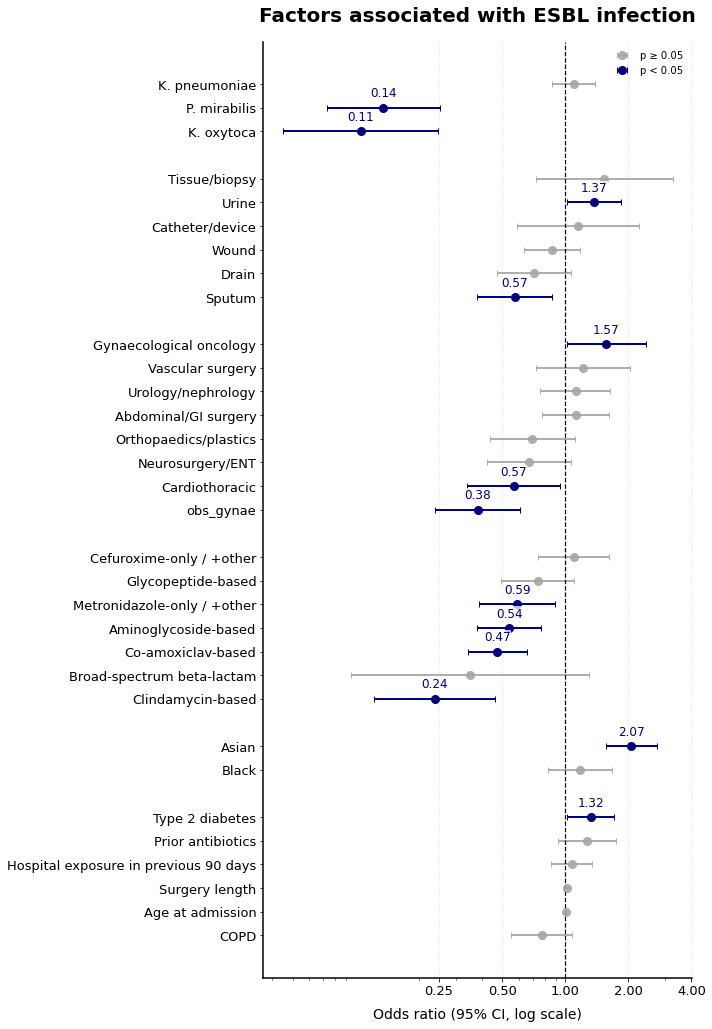

In [17]:
plot_df = plot_adjusted_or_forest(or_df)